# Topological Analysis of Heterogeneous Treatment Effects

Companion notebook for the bachelor's thesis of **Apollonov N. A.** (HSE Faculty of Mathematics).

This notebook walks through the full pipeline:

1. **Data.** Synthetic data from the heterogeneous PLM $Y = g_0(X) + A\,\tau_0(X) + U$, with a *known* CATE $\tau_0$ whose superlevel-set topology is controlled by us.
2. **Estimation.** Cross-fitted residualization $\widetilde Y_i = Y_i - \widehat m^{(-k(i))}(X_i),\ \widetilde A_i = A_i - \widehat e^{(-k(i))}(X_i)$, then a regularised non-parametric second stage (R-learner-style) to obtain $\widehat\tau_n$.
3. **Geometry.** Shape-regular triangulation $K_h$ of $\Omega = [0,1]^2$ and PL interpolation $f_{n,h}$ of $\widehat\tau_n$ on the vertices of $K_h$.
4. **Topology.** Persistent homology of the sublevel filtration of $-f_{n,h}$ (equivalently, the superlevel filtration of $f_{n,h}$) computed with `ripser`.
5. **Landscape.** Persistence landscape $\Lambda_0(f_{n,h})$ with discrete $L_p$ norms.
6. **Empirical checks.** Stability $\|\Lambda_0(f) - \Lambda_0(g)\|_p \le C_p\,\|f-g\|_\infty$ and convergence $\|\Lambda_0(f_{n,h}) - \Lambda_0(\tau_0)\|_p = O_P(r_n + h^\alpha)$.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src import data, cate, triangulation, topology, landscape, plotting

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Data generation

We use the custom topology-controlled DGP. The ground-truth $\tau_0$ is a sum of two Gaussian bumps -- so $\beta_0(A_t(\tau_0)) = 2$ for thresholds $t$ in a non-trivial range, which is the topological feature we want to recover.

A wrapper around `doubleml.datasets.make_plr_CCDDHNR2018` is also available (`data.make_doubleml_data`), but produces a *constant* CATE.

n = 4000   d = 2   treated fraction = 0.515


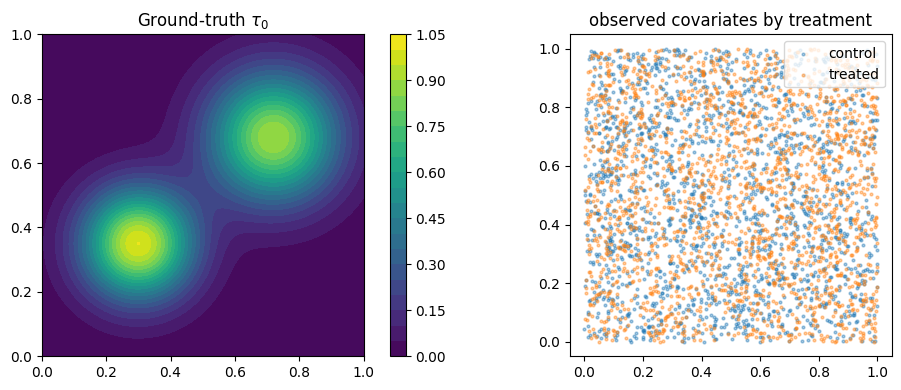

In [2]:
ds = data.make_topology_dgp(n=4000, topology='two_blobs', noise_sd=0.05, seed=0)
print('n =', ds.n, '  d =', ds.d, '  treated fraction =', ds.A.mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plotting.plot_function_2d(ds.tau0, title=r'Ground-truth $\tau_0$', ax=axes[0])
axes[1].scatter(ds.X[ds.A == 0, 0], ds.X[ds.A == 0, 1], s=4, alpha=0.4, label='control')
axes[1].scatter(ds.X[ds.A == 1, 0], ds.X[ds.A == 1, 1], s=4, alpha=0.4, label='treated')
axes[1].set_aspect('equal'); axes[1].legend(); axes[1].set_title('observed covariates by treatment')
plt.tight_layout(); plt.show()

### DoubleML compatibility check

Just to confirm that the rest of the pipeline accepts a DoubleML-style dataset (even though its $\tau_0$ is constant).

In [3]:
# The CCDDHNR2018 DGP touches the first three covariates, so dim_x >= 3 is required.
ds_dml = data.make_doubleml_data(n=500, dim_x=5, seed=0)
print('DoubleML dataset:  n =', ds_dml.n, ' d =', ds_dml.d,
      ' mean Y =', ds_dml.Y.mean().round(3))

DoubleML dataset:  n = 500  d = 5  mean Y = 0.515


## 2. Cross-fitted residualization + R-learner

We fit

$$\widehat\tau_n \in \arg\min_{\tau\in\mathcal F_n}
\frac1n\sum_i \bigl(\widetilde Y_i - \widetilde A_i\,\tau(X_i)\bigr)^2 + \mathrm{pen}_n(\tau),$$

with $\mathcal F_n$ a gradient-boosted-tree class (KRR is also available via `backend='krr'`).

in-sample RMSE = 0.0261    sup-norm error ~ 0.1393


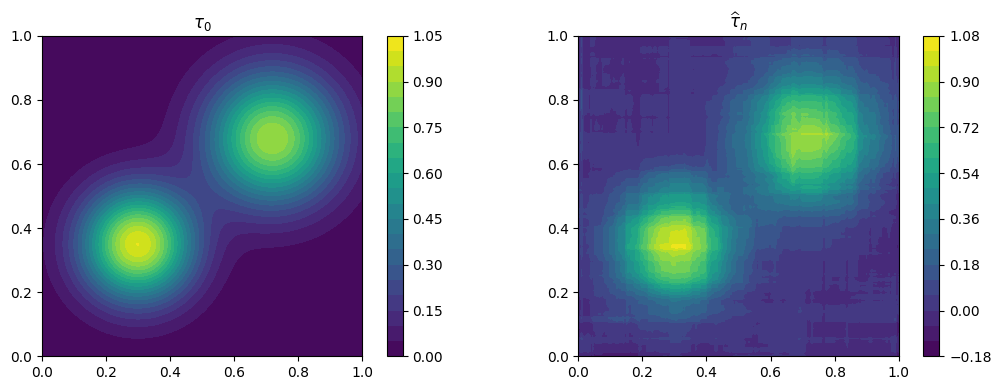

In [4]:
tau_hat = cate.RLearnerCATE(backend='catboost', n_folds=5, seed=0).fit(ds.X, ds.A, ds.Y)

# in-sample sanity check vs. the truth
true_vals = ds.tau0(ds.X)
pred_vals = tau_hat.predict(ds.X)
rmse = float(np.sqrt(np.mean((pred_vals - true_vals) ** 2)))
sup = float(np.max(np.abs(pred_vals - true_vals)))
print(f'in-sample RMSE = {rmse:.4f}    sup-norm error ~ {sup:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plotting.plot_function_2d(ds.tau0,         title=r'$\tau_0$',            ax=axes[0])
plotting.plot_function_2d(tau_hat.predict, title=r'$\widehat\tau_n$', ax=axes[1])
plt.tight_layout(); plt.show()

## 3. Triangulation and PL interpolation

We use a uniform structured triangulation of $[0,1]^2$ with $n_{\mathrm{side}}$ vertices per axis; the mesh size $h$ equals the diagonal of a single cell.

mesh: V = 2601, T = 5000, h = 0.0283


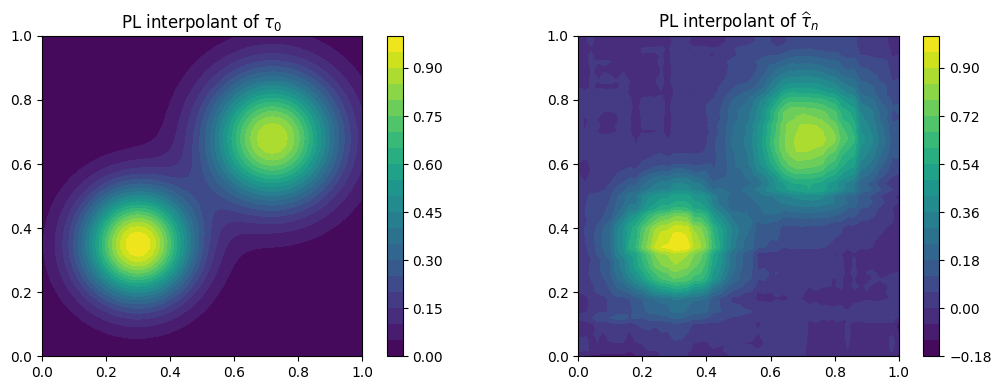

In [5]:
mesh = triangulation.uniform_triangulation_2d(n_per_side=51, domain=ds.domain)
print(f'mesh: V = {mesh.n_vertices}, T = {mesh.simplices.shape[0]}, h = {mesh.h:.4f}')

f_true_vals = triangulation.pl_interpolate(ds.tau0,         mesh)
f_hat_vals  = triangulation.pl_interpolate(tau_hat.predict, mesh)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plotting.plot_pl_function(f_true_vals, mesh, title=r'PL interpolant of $\tau_0$',         ax=axes[0])
plotting.plot_pl_function(f_hat_vals,  mesh, title=r'PL interpolant of $\widehat\tau_n$', ax=axes[1])
plt.tight_layout(); plt.show()

## 4. Persistent homology of superlevel sets ($q = 0$)

Via `ripser` with the lower-star filtration of $-f_h$. We display the diagram both in the original $f$-coordinates ("superlevel" view) and in $-f$-coordinates (raw `ripser` output).

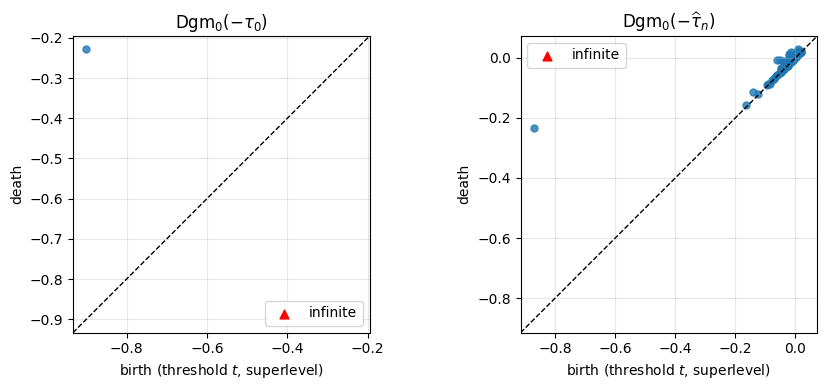

In [6]:
dgm_true_f   = topology.persistence_h0_superlevel(f_true_vals, mesh, return_in_f_coords=True)
dgm_true_neg = topology.persistence_h0_superlevel(f_true_vals, mesh, return_in_f_coords=False)
dgm_hat_f    = topology.persistence_h0_superlevel(f_hat_vals,  mesh, return_in_f_coords=True)
dgm_hat_neg  = topology.persistence_h0_superlevel(f_hat_vals,  mesh, return_in_f_coords=False)

# print('finite (b, d) points (superlevel, in -f coords)')
# print('  truth :', topology.diagram_finite_part(dgm_true_neg).round(3))
# print('  est.  :', topology.diagram_finite_part(dgm_hat_neg).round(3))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plotting.plot_diagram(dgm_true_neg, title=r'$\mathrm{Dgm}_0(-\tau_0)$',         ax=axes[0])
plotting.plot_diagram(dgm_hat_neg,  title=r'$\mathrm{Dgm}_0(-\widehat\tau_n)$', ax=axes[1])
plt.tight_layout() 
plt.show()

## 5. Persistence landscapes and their $L_p$ norms

In [ ]:
grid = landscape.auto_grid([dgm_true_neg, dgm_hat_neg], n_points=512, pad=0.1)
L_true = landscape.compute_landscape(dgm_true_neg, grid)
L_hat  = landscape.compute_landscape(dgm_hat_neg,  grid)

for p in (1.0, 2.0, np.inf):
    d_p = landscape.landscape_distance(L_true, L_hat, p=p)
    print(f'||Lambda_0(tau0) - Lambda_0(tau_hat)||_{p} = {d_p:.4f}')
print(f'sup-norm  ||tau_hat - tau0||_inf (MC)        = {triangulation.sup_norm_error(ds.tau0, f_hat_vals, mesh):.4f}')

# Bootstrap scale estimates for the estimated landscape (no knowledge of tau_0)
scales = cate.estimate_tau_scales(ds.X, ds.A, ds.Y, X_grid=mesh.vertices, n_bootstrap=20, seed=0, alpha=0.5)
print(f'amp_minmax(tau_hat) = {scales.amplitude_minmax:.3f}, amp_bootstrap = {scales.amplitude_bootstrap:.3f}, eps_n = {scales.eps_n:.3f}')
amp_true = float(f_true_vals.max() - f_true_vals.min())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plotting.plot_landscape(L_true, title=r'$\Lambda_0(\tau_0)$',         ax=axes[0],
                        amplitude_minmax=amp_true)
plotting.plot_landscape(L_hat,  title=r'$\Lambda_0(\widehat\tau_n)$', ax=axes[1],
                        amplitude_bootstrap=scales.amplitude_bootstrap,
                        eps_n=None)
plt.tight_layout(); plt.show()

||Lambda_0(tau0) - Lambda_0(tau_hat)||_1.0 = 0.0146
||Lambda_0(tau0) - Lambda_0(tau_hat)||_2.0 = 0.0181
||Lambda_0(tau0) - Lambda_0(tau_hat)||_inf = 0.0297
sup-norm  ||tau_hat - tau0||_inf (MC)        = 0.1282


## 6. Deterministic stability check

Empirically check the bound targeted in the thesis:

$$\|\Lambda_0(f) - \Lambda_0(g)\|_p \;\le\; C_p\,\|f - g\|_\infty.$$

We perturb $\tau_0$ at the mesh nodes by uniform noise of varying amplitude $\varepsilon$ and check that the resulting landscape distance is bounded *linearly* by $\varepsilon$.

 eps   |f-g|_inf  L1     L2     Linf
0.000   0.0000  0.0000  0.0000  0.0000
0.025   0.0250  0.0125  0.0098  0.0137
0.050   0.0500  0.0614  0.0388  0.0474
0.075   0.0750  0.1155  0.0519  0.0514
0.100   0.1000  0.2206  0.0853  0.0882
0.125   0.1248  0.3931  0.1254  0.1178
0.150   0.1500  0.6413  0.1667  0.1182
0.175   0.1749  0.7743  0.1967  0.1368
0.200   0.2000  1.1127  0.2506  0.1377
0.225   0.2249  1.4591  0.3019  0.1649
0.250   0.2497  1.6771  0.3354  0.1889
0.275   0.2748  1.9295  0.3813  0.2274
0.300   0.2999  2.7650  0.4790  0.2560


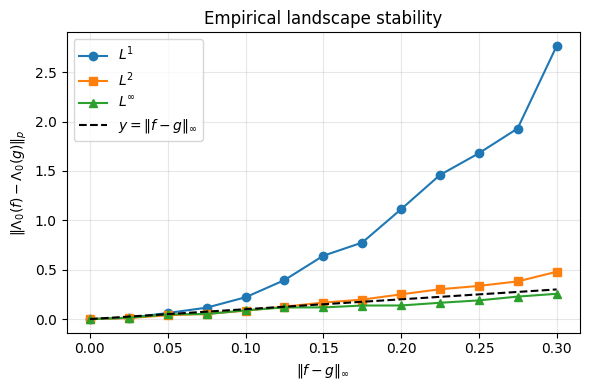

In [8]:
rng = np.random.default_rng(123)
epsilons = np.linspace(0.0, 0.3, 13)
rows = []
for eps in epsilons:
    noise = rng.uniform(-eps, eps, size=mesh.n_vertices)
    f_perturbed = f_true_vals + noise
    actual_sup = float(np.max(np.abs(noise)))
    dgm_eps = topology.persistence_h0_superlevel(f_perturbed, mesh, return_in_f_coords=False)
    g_local = landscape.auto_grid([dgm_true_neg, dgm_eps], n_points=512, pad=0.1)
    L0 = landscape.compute_landscape(dgm_true_neg, g_local)
    Le = landscape.compute_landscape(dgm_eps,      g_local)
    rows.append((eps, actual_sup,
                 landscape.landscape_distance(L0, Le, p=1.0),
                 landscape.landscape_distance(L0, Le, p=2.0),
                 landscape.landscape_distance(L0, Le, p=np.inf)))

arr = np.asarray(rows)
print(' eps   |f-g|_inf  L1     L2     Linf')
for row in arr:
    print('{:5.3f}  {:7.4f}  {:6.4f}  {:6.4f}  {:6.4f}'.format(*row))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(arr[:, 1], arr[:, 2], 'o-', label=r'$L^1$')
ax.plot(arr[:, 1], arr[:, 3], 's-', label=r'$L^2$')
ax.plot(arr[:, 1], arr[:, 4], '^-', label=r'$L^\infty$')
ax.plot(arr[:, 1], arr[:, 1], 'k--', label=r'$y = \|f - g\|_\infty$')
ax.set_xlabel(r'$\|f - g\|_\infty$'); ax.set_ylabel(r'$\|\Lambda_0(f) - \Lambda_0(g)\|_p$')
ax.set_title('Empirical landscape stability'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Geometric (triangulation) error $h^\alpha$

Vary the mesh size $h$ for the *exact* function $\tau_0$ (no statistical error) and check both

* $\|\tau_{0,h} - \tau_0\|_\infty \lesssim h^\alpha$ (here $\alpha = 2$ because $\tau_0 \in C^\infty$ and we use $P_1$ on a shape-regular family),
* $\|\Lambda_0(\tau_{0,h}) - \Lambda_0(\tau_0)\|_p \lesssim h^\alpha$.

We treat the finest mesh as a stand-in for the limit $h\downarrow 0$.

  n_side    h        sup-err     L2-land     Linf-land
    11    0.1414    0.13595    0.02237    0.03535
    17    0.0884    0.06023    0.01707    0.02172
    25    0.0589    0.02842    0.00556    0.00713
    35    0.0416    0.01416    0.00282    0.00482
    51    0.0283    0.00651    0.00002    0.00003
    71    0.0202    0.00328    0.00087    0.00150


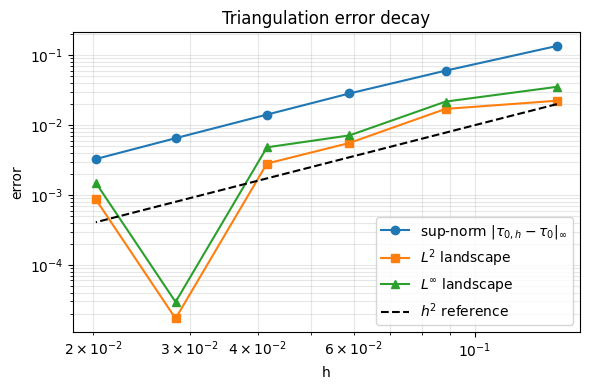

In [9]:
n_sides = [11, 17, 25, 35, 51, 71, 101]
meshes = [triangulation.uniform_triangulation_2d(n, domain=ds.domain) for n in n_sides]
vals   = [triangulation.pl_interpolate(ds.tau0, m) for m in meshes]
dgms   = [topology.persistence_h0_superlevel(v, m, return_in_f_coords=False)
          for v, m in zip(vals, meshes)]
ref_dgm = dgms[-1]
g_ref = landscape.auto_grid([ref_dgm] + dgms, n_points=512, pad=0.1)
L_ref = landscape.compute_landscape(ref_dgm, g_ref)

rows = []
for n, m, v, d in zip(n_sides[:-1], meshes[:-1], vals[:-1], dgms[:-1]):
    sup = triangulation.sup_norm_error(ds.tau0, v, m, n_test=8000, seed=0)
    Lh = landscape.compute_landscape(d, g_ref)
    rows.append((n, m.h, sup,
                 landscape.landscape_distance(L_ref, Lh, p=2.0),
                 landscape.landscape_distance(L_ref, Lh, p=np.inf)))

arr = np.asarray(rows)
print('  n_side    h        sup-err     L2-land     Linf-land')
for r in arr:
    print('{:6.0f}   {:7.4f}   {:8.5f}   {:8.5f}   {:8.5f}'.format(*r))

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(arr[:, 1], arr[:, 2], 'o-', label='sup-norm $|\\tau_{0,h}-\\tau_0|_\\infty$')
ax.loglog(arr[:, 1], arr[:, 3], 's-', label='$L^2$ landscape')
ax.loglog(arr[:, 1], arr[:, 4], '^-', label='$L^\\infty$ landscape')
ax.loglog(arr[:, 1], arr[:, 1] ** 2, 'k--', label='$h^2$ reference')
ax.set_xlabel('h'); ax.set_ylabel('error'); ax.grid(alpha=0.3, which='both'); ax.legend()
ax.set_title('Triangulation error decay'); plt.tight_layout(); plt.show()

## 8. Statistical consistency: $O_P(r_n + h^\alpha)$

Monte-Carlo: for a few sample sizes $n$, repeat

* generate fresh data,
* fit $\widehat\tau_n$ by the R-learner,
* compute $\Lambda_0(f_{n,h})$ on a fixed mesh,

and measure the average landscape distance to $\Lambda_0(\tau_0)$. This is a numerical illustration of the planned consistency theorem of Section 4.3.

n=500: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:12<00:00,  2.45s/it]


n =   500    L2-dist mean = 1.3178   std = 1.0865


n=1000: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:15<00:00,  3.16s/it]


n =  1000    L2-dist mean = 0.5879   std = 0.4758


n=2000: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:22<00:00,  4.60s/it]


n =  2000    L2-dist mean = 0.3668   std = 0.1680


n=4000: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:38<00:00,  7.60s/it]


n =  4000    L2-dist mean = 0.2157   std = 0.0379


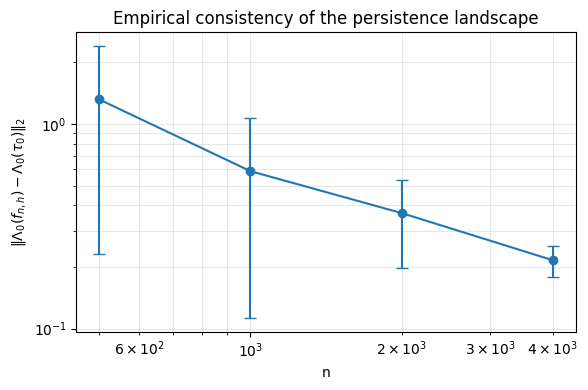

In [10]:
from tqdm import tqdm

tau0 = data.make_tau0('two_blobs')
mesh_fixed = triangulation.uniform_triangulation_2d(n_per_side=41)
f_true = triangulation.pl_interpolate(tau0, mesh_fixed)
dgm_true = topology.persistence_h0_superlevel(f_true, mesh_fixed, return_in_f_coords=False)

sample_sizes = [500, 1000, 2000, 4000]
n_reps = 5
summary = []
for n in sample_sizes:
    dists = []
    for rep in tqdm(range(n_reps), desc=f'n={n}'):
        ds_n = data.make_topology_dgp(n=n, topology='two_blobs', noise_sd=0.3, seed=1000 + rep)
        est = cate.RLearnerCATE(backend='gbr', n_folds=5, seed=rep).fit(ds_n.X, ds_n.A, ds_n.Y)
        f_nh = triangulation.pl_interpolate(est.predict, mesh_fixed)
        dgm_n = topology.persistence_h0_superlevel(f_nh, mesh_fixed, return_in_f_coords=False)
        g = landscape.auto_grid([dgm_true, dgm_n], n_points=512, pad=0.1)
        L0 = landscape.compute_landscape(dgm_true, g)
        Ln = landscape.compute_landscape(dgm_n,    g)
        dists.append(landscape.landscape_distance(L0, Ln, p=2.0))
    summary.append((n, float(np.mean(dists)), float(np.std(dists))))
    print(f'n = {n:5d}    L2-dist mean = {summary[-1][1]:.4f}   std = {summary[-1][2]:.4f}')

arr = np.asarray(summary)
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(arr[:, 0], arr[:, 1], yerr=arr[:, 2], marker='o', capsize=4)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('n'); ax.set_ylabel(r'$\|\Lambda_0(f_{n,h}) - \Lambda_0(\tau_0)\|_2$')
ax.set_title('Empirical consistency of the persistence landscape')
ax.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()

## 9. Comparison across topologies

Quick illustration that the diagrams/landscapes distinguish the three pre-defined topologies (single bump / two bumps / annulus). In $q = 0$, the *annulus* DGP behaves like a single connected high-effect region, while *two_blobs* yields two persistent components -- exactly the kind of qualitative distinction the thesis aims to make rigorous.

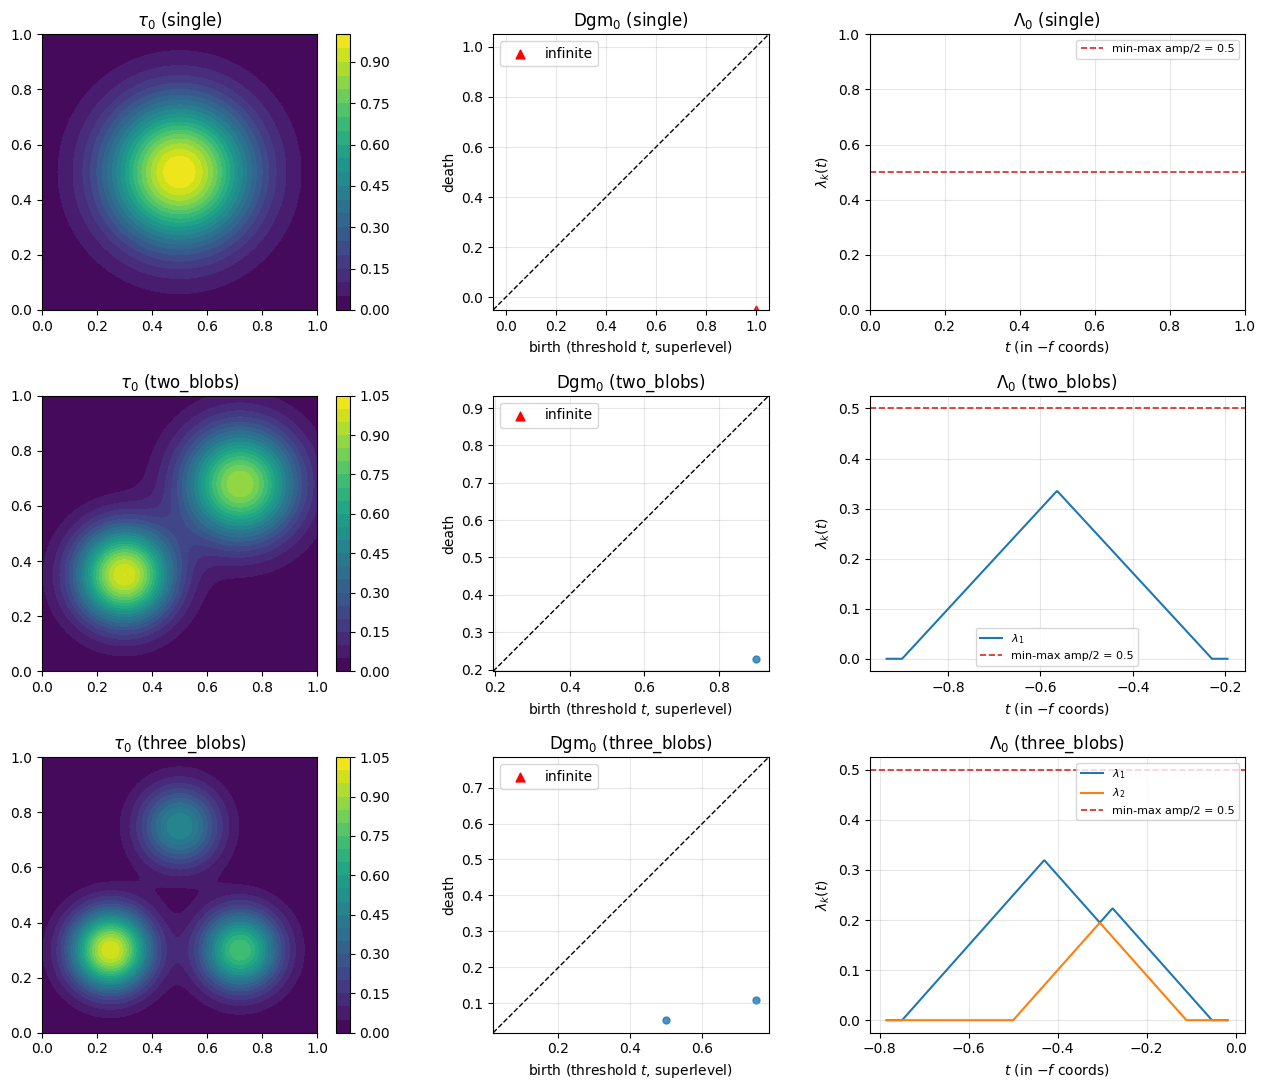

In [48]:
topo_list = ['single', 'two_blobs', 'three_blobs']
mesh_demo = triangulation.uniform_triangulation_2d(n_per_side=61)
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for row, topo in enumerate(topo_list):
    t0 = data.make_tau0(topo)
    nodal = triangulation.pl_interpolate(t0, mesh_demo)
    dgm_f   = topology.persistence_h0_superlevel(nodal, mesh_demo, return_in_f_coords=True)
    dgm_neg = topology.persistence_h0_superlevel(nodal, mesh_demo, return_in_f_coords=False)
    L = landscape.compute_landscape(dgm_neg, landscape.auto_grid(dgm_neg, n_points=512))
    amp_true = float(nodal.max() - nodal.min())
    plotting.plot_pl_function(nodal, mesh_demo, title=fr'$\tau_0$ ({topo})', ax=axes[row, 0])
    plotting.plot_diagram(dgm_f, title=fr'Dgm$_0$ ({topo})',                ax=axes[row, 1])
    plotting.plot_landscape(L, title=fr'$\Lambda_0$ ({topo})',              ax=axes[row, 2],
                            amplitude_minmax=amp_true)
plt.tight_layout(); plt.show()

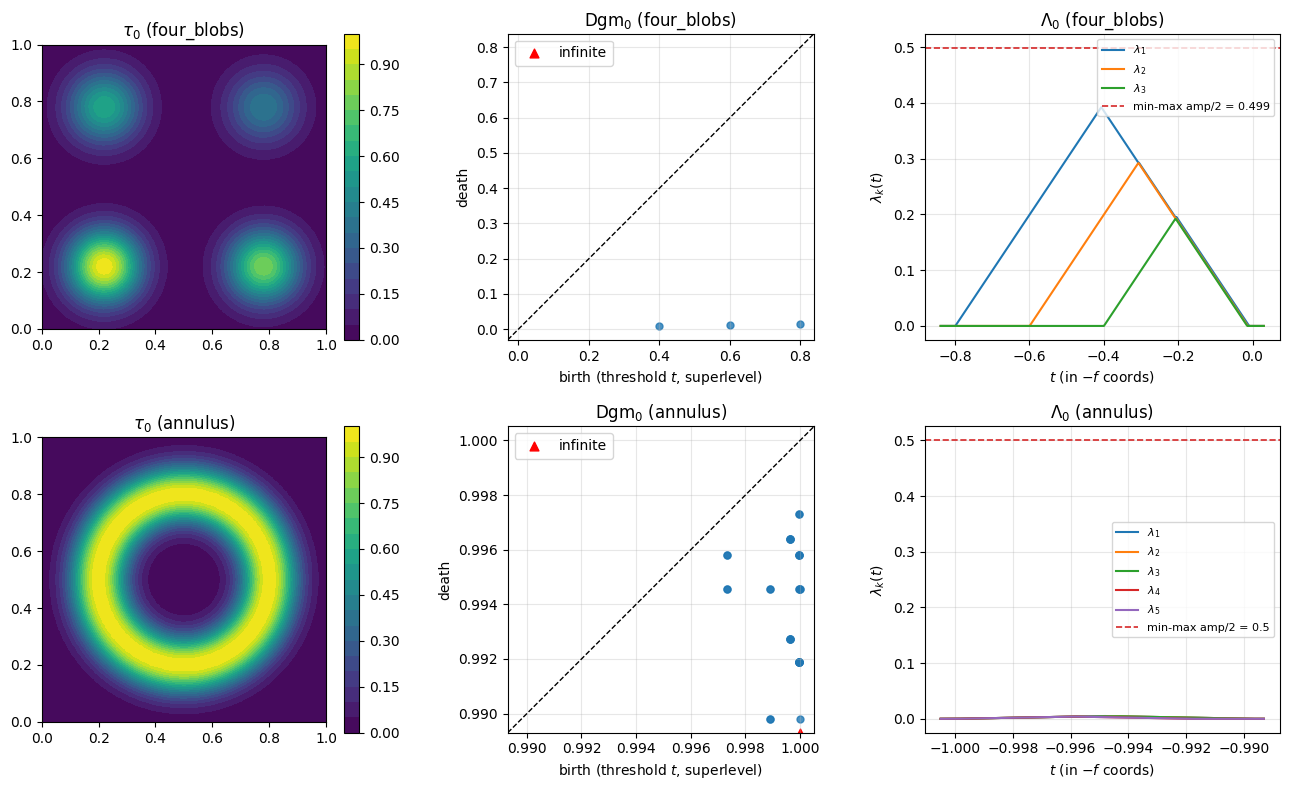

In [53]:
topo_list = ['four_blobs', 'annulus']
mesh_demo = triangulation.uniform_triangulation_2d(n_per_side=61)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, topo in enumerate(topo_list):
    t0 = data.make_tau0(topo)
    nodal = triangulation.pl_interpolate(t0, mesh_demo)
    dgm_f   = topology.persistence_h0_superlevel(nodal, mesh_demo, return_in_f_coords=True)
    dgm_neg = topology.persistence_h0_superlevel(nodal, mesh_demo, return_in_f_coords=False)
    L = landscape.compute_landscape(dgm_neg, landscape.auto_grid(dgm_neg, n_points=512))
    amp_true = float(nodal.max() - nodal.min())
    plotting.plot_pl_function(nodal, mesh_demo, title=fr'$\tau_0$ ({topo})', ax=axes[row, 0])
    plotting.plot_diagram(dgm_f, title=fr'Dgm$_0$ ({topo})',                ax=axes[row, 1])
    plotting.plot_landscape(L, title=fr'$\Lambda_0$ ({topo})',              ax=axes[row, 2],
                            amplitude_minmax=amp_true)
plt.tight_layout(); plt.show()

### 9.1 Richer ground-truth topologies: three and four bumps

On `two_blobs` the ground-truth landscape $\Lambda_0(\tau_0)$ has only **one** non-zero tent (Section 1 of the notebook explains why: two bumps merge through a single saddle, so $\mathrm{Dgm}_0(-\tau_0)$ has one finite point plus one essential class). To make the convergence target more informative we add two new presets:

* `'three_blobs'` -- three well-separated Gaussian bumps of heights $1.0/0.75/0.50$. Expected ground truth: $\mathrm{Dgm}_0$ with $1$ infinite + $2$ finite points; $\Lambda_0$ with $2$ non-zero tents of decreasing height.
* `'four_blobs'`  -- four well-separated bumps of heights $1.0/0.80/0.60/0.40$. Expected ground truth: $1$ infinite + $3$ finite points in $\mathrm{Dgm}_0$; $3$ non-zero tents in $\Lambda_0$.

For each preset we run the full pipeline (R-learner + PL interpolation + persistent homology + landscape) at two sample sizes -- a *moderate* one and a *large* one -- and compare the estimated landscape $\Lambda_0(\widehat\tau_n)$ against the ground-truth $\Lambda_0(\tau_0)$. The pluggable second-stage backend defaults to **CatBoost**; `xgboost` and `gbr` are also available (see `cate.RLearnerCATE`).

In [12]:
def run_topology_experiment(topo, n, mesh, backend='catboost', noise_sd=0.3, seed=0, n_bootstrap=20, noise_band_alpha=0.68):
    """Run the full pipeline once for the given topology preset and sample size.

    Returns a dict with the PL nodal values, persistence diagrams (both in -f
    coords for landscape computation and in f-coords for plotting), landscapes
    on a common grid, the L^1 / L^2 / L^inf landscape distances between the
    truth and the estimate, and bootstrap-based scale estimates
    (amplitude_minmax / amplitude_bootstrap / eps_n) of tau_hat.
    """
    ds = data.make_topology_dgp(n=n, topology=topo, noise_sd=noise_sd, seed=seed)
    est = cate.RLearnerCATE(backend=backend, n_folds=5, seed=seed).fit(ds.X, ds.A, ds.Y)

    f_true_vals = triangulation.pl_interpolate(ds.tau0,    mesh)
    f_hat_vals  = triangulation.pl_interpolate(est.predict, mesh)

    dgm_true_f   = topology.persistence_h0_superlevel(f_true_vals, mesh, return_in_f_coords=True)
    dgm_true_neg = topology.persistence_h0_superlevel(f_true_vals, mesh, return_in_f_coords=False)
    dgm_hat_f    = topology.persistence_h0_superlevel(f_hat_vals,  mesh, return_in_f_coords=True)
    dgm_hat_neg  = topology.persistence_h0_superlevel(f_hat_vals,  mesh, return_in_f_coords=False)

    grid = landscape.auto_grid([dgm_true_neg, dgm_hat_neg], n_points=512, pad=0.1)
    L_true = landscape.compute_landscape(dgm_true_neg, grid)
    L_hat  = landscape.compute_landscape(dgm_hat_neg,  grid)

    dists = {
        'L1':   landscape.landscape_distance(L_true, L_hat, p=1.0),
        'L2':   landscape.landscape_distance(L_true, L_hat, p=2.0),
        'Linf': landscape.landscape_distance(L_true, L_hat, p=np.inf),
    }
    scales = cate.estimate_tau_scales(
        ds.X, ds.A, ds.Y, X_grid=mesh.vertices,
        backend=backend, n_folds=5, n_bootstrap=n_bootstrap, seed=seed, alpha=noise_band_alpha
    )
    amp_true = float(f_true_vals.max() - f_true_vals.min())
    return {
        'ds':       ds,
        'mesh':     mesh,
        'f_true':   f_true_vals,    'f_hat':   f_hat_vals,
        'dgm_true_f': dgm_true_f,   'dgm_hat_f': dgm_hat_f,
        'dgm_true_neg': dgm_true_neg, 'dgm_hat_neg': dgm_hat_neg,
        'L_true':   L_true,         'L_hat':   L_hat,
        'dists':    dists,
        'scales':   scales,
        'amp_true': amp_true,
    }

[ run ] topo=three_blobs   n= 2000  backend=catboost
[ run ] topo=three_blobs   n= 8000  backend=catboost
[ run ] topo=four_blobs    n= 2000  backend=catboost
[ run ] topo=four_blobs    n= 8000  backend=catboost

--- landscape distances ||Lambda_0(tau_hat) - Lambda_0(tau_0)||_p ---
topology           n          L1          L2        Linf
three_blobs     2000      0.0716      0.0665      0.1000
three_blobs     8000      0.0401      0.0366      0.0482
four_blobs      2000      0.0833      0.0785      0.1178
four_blobs      8000      0.0458      0.0395      0.0622


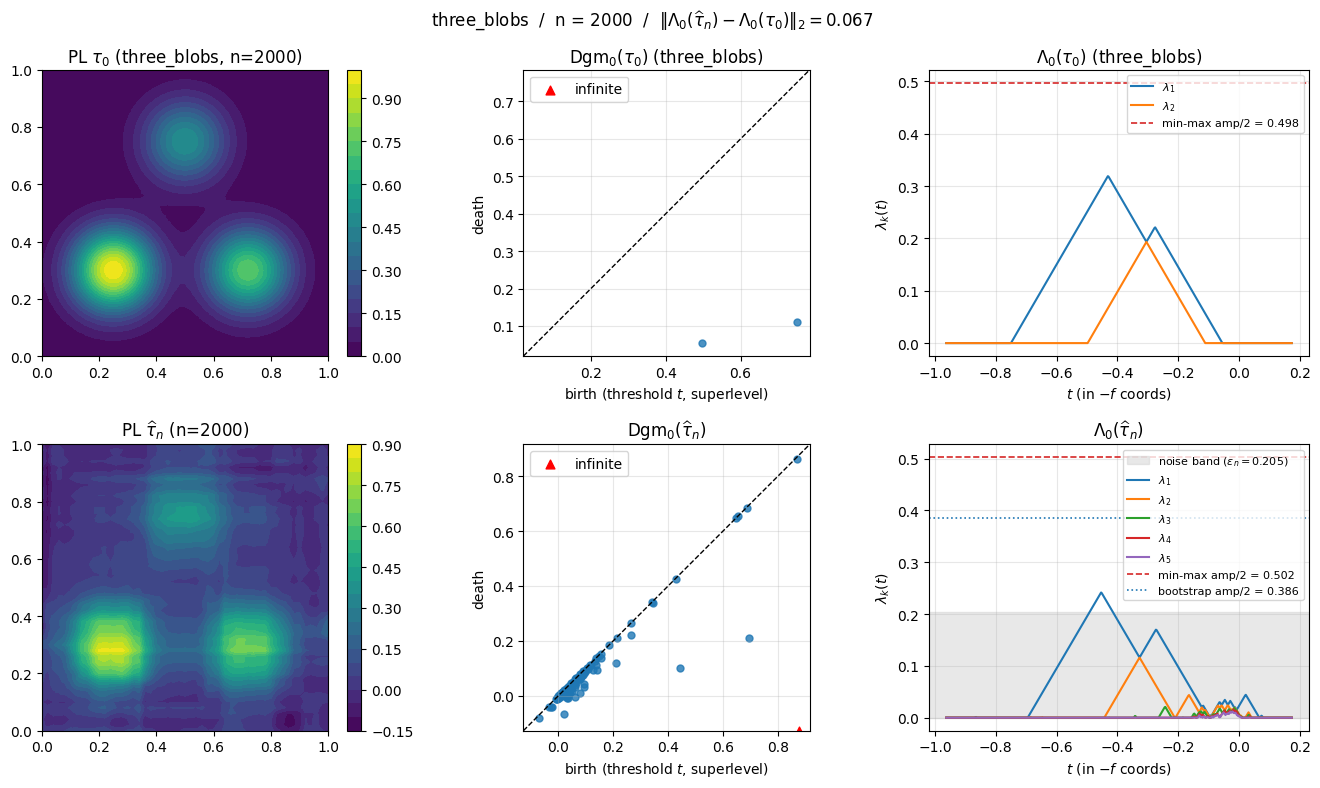

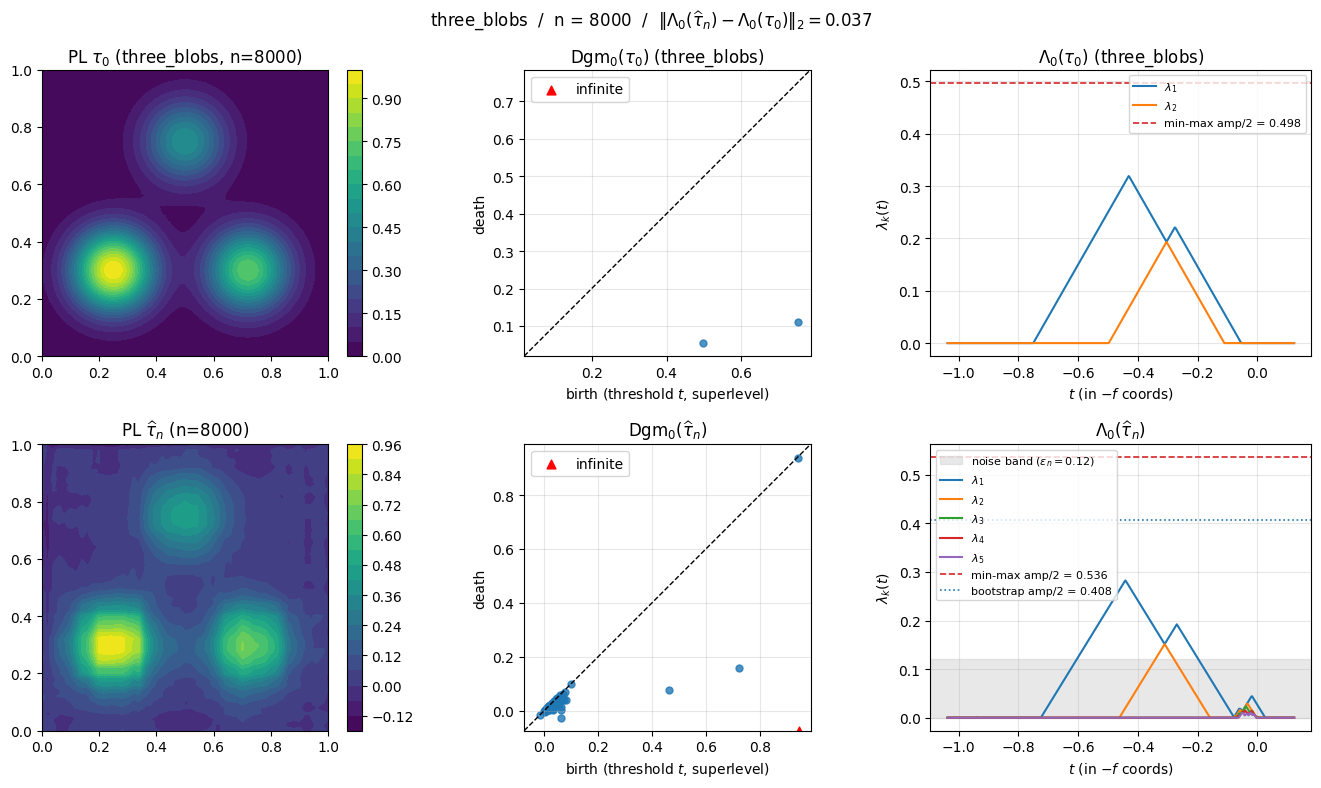

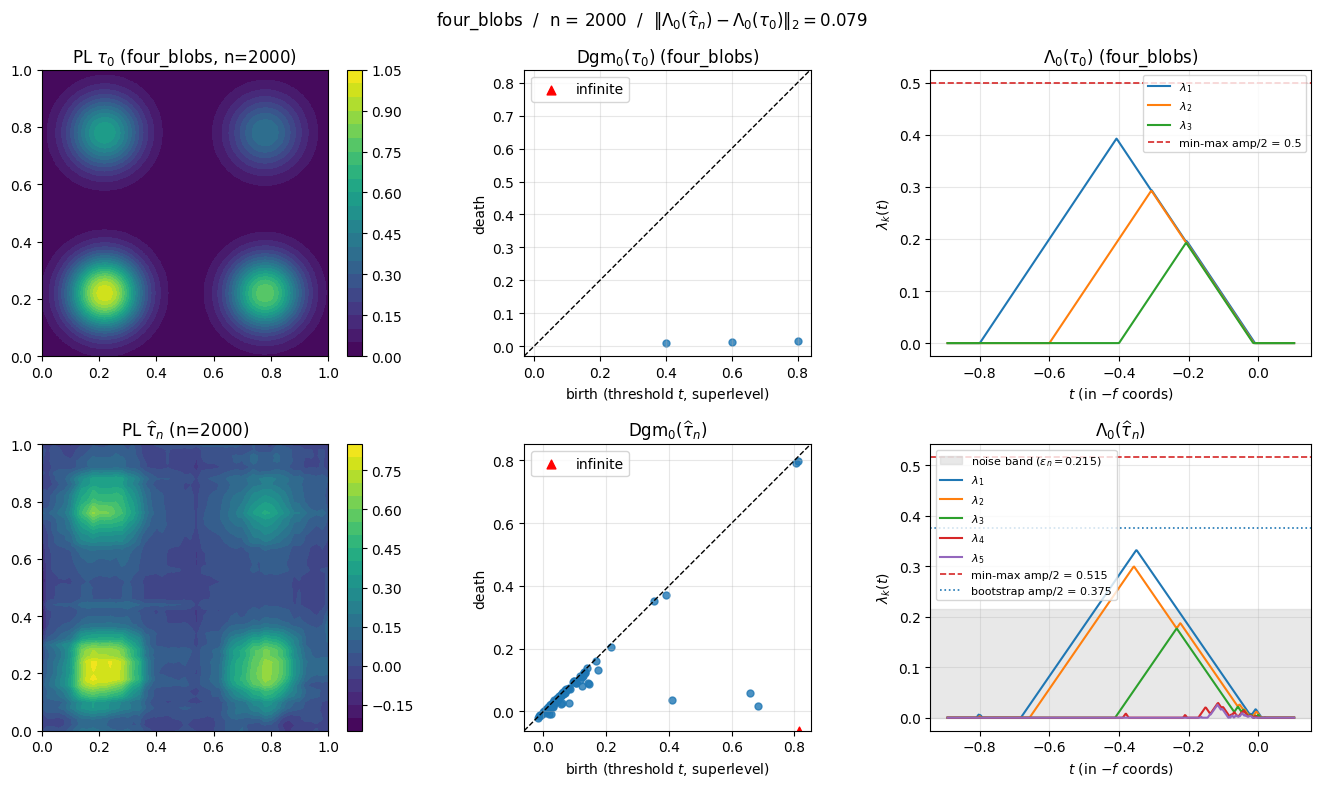

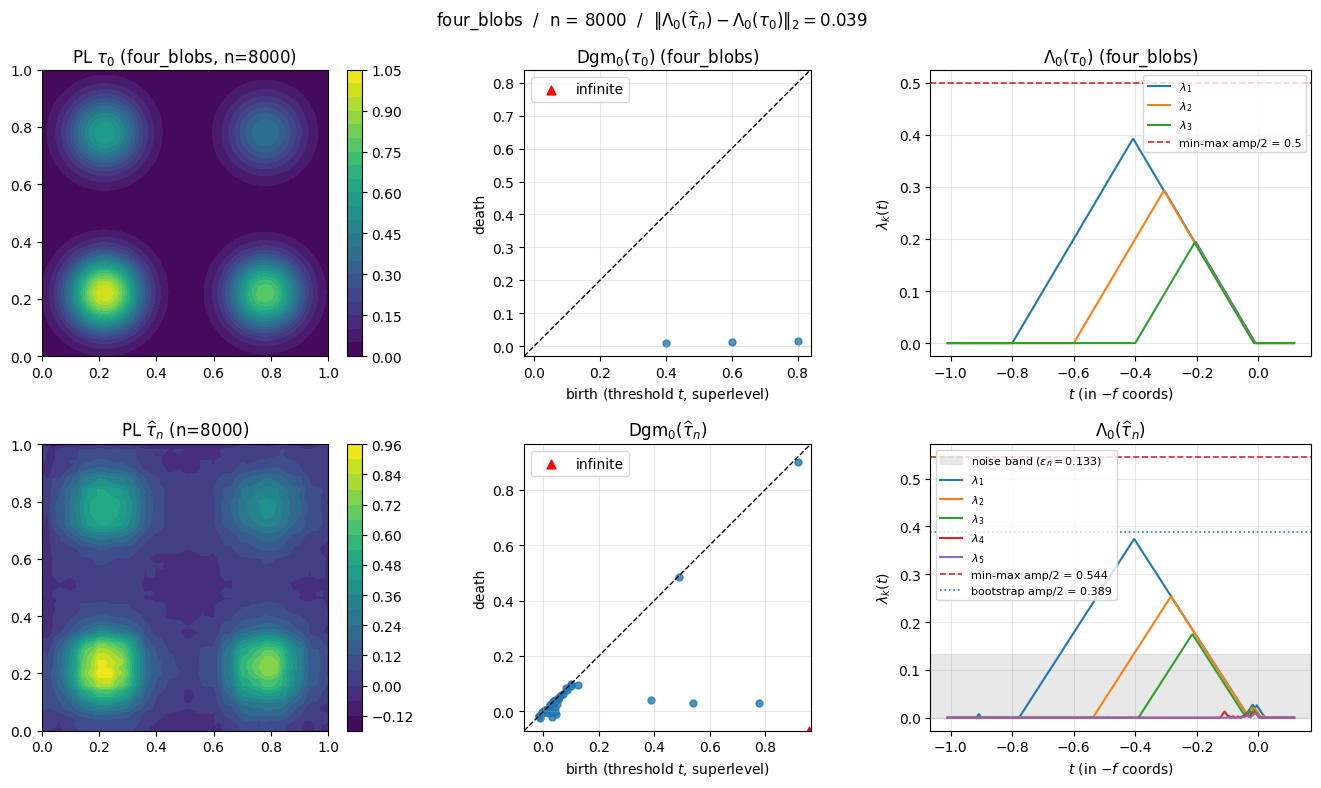

In [13]:
mesh_richer = triangulation.uniform_triangulation_2d(n_per_side=51)
BACKEND = 'catboost'    # try also 'xgboost', 'gbr'

topo_list = ['three_blobs', 'four_blobs']
n_list    = [2000, 8000]

results = {}
for topo in topo_list:
    for n in n_list:
        print(f'[ run ] topo={topo:12s}  n={n:5d}  backend={BACKEND}')
        results[(topo, n)] = run_topology_experiment(topo, n, mesh_richer, backend=BACKEND, noise_sd=0.05, seed=0, noise_band_alpha=0.5)

print('\n--- landscape distances ||Lambda_0(tau_hat) - Lambda_0(tau_0)||_p ---')
print(f'{"topology":12s}  {"n":>6s}    {"L1":>8s}    {"L2":>8s}    {"Linf":>8s}')
for (topo, n), res in results.items():
    d = res['dists']
    print(f'{topo:12s}  {n:6d}    {d["L1"]:8.4f}    {d["L2"]:8.4f}    {d["Linf"]:8.4f}')

for topo in topo_list:
    for n in n_list:
        res = results[(topo, n)]
        fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
        plotting.plot_pl_function(res['f_true'], mesh_richer, title=fr'PL $\tau_0$ ({topo}, n={n})', ax=axes[0, 0])
        plotting.plot_diagram(res['dgm_true_f'], title=fr'$\mathrm{{Dgm}}_0(\tau_0)$ ({topo})',     ax=axes[0, 1])
        plotting.plot_landscape(res['L_true'], title=fr'$\Lambda_0(\tau_0)$ ({topo})',              ax=axes[0, 2],
                                amplitude_minmax=res['amp_true'])
        plotting.plot_pl_function(res['f_hat'],  mesh_richer, title=fr'PL $\widehat\tau_n$ (n={n})', ax=axes[1, 0])
        plotting.plot_diagram(res['dgm_hat_f'],  title=fr'$\mathrm{{Dgm}}_0(\widehat\tau_n)$',       ax=axes[1, 1])
        plotting.plot_landscape(res['L_hat'],    title=fr'$\Lambda_0(\widehat\tau_n)$',              ax=axes[1, 2],
                                amplitude_minmax=res['scales'].amplitude_minmax,
                                amplitude_bootstrap=res['scales'].amplitude_bootstrap,
                                eps_n=res['scales'].eps_n)
        d = res['dists']
        fig.suptitle(fr'{topo}  /  n = {n}  /  '
                     fr'$\|\Lambda_0(\widehat\tau_n)-\Lambda_0(\tau_0)\|_2={d["L2"]:.3f}$',
                     fontsize=12)
        plt.tight_layout(); plt.show()

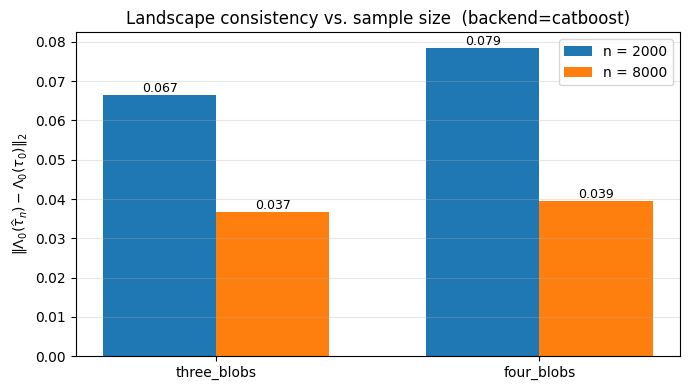

In [14]:
# Side-by-side comparison: L^2 landscape distance at moderate vs. large n.
labels = topo_list
x = np.arange(len(labels))
width = 0.35
vals_lo = [results[(t, n_list[0])]['dists']['L2'] for t in labels]
vals_hi = [results[(t, n_list[1])]['dists']['L2'] for t in labels]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, vals_lo, width, label=f'n = {n_list[0]}')
ax.bar(x + width / 2, vals_hi, width, label=f'n = {n_list[1]}')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel(r'$\|\Lambda_0(\widehat\tau_n) - \Lambda_0(\tau_0)\|_2$')
ax.set_title(f'Landscape consistency vs. sample size  (backend={BACKEND})')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for xi, v in zip(x - width / 2, vals_lo):
    ax.text(xi, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for xi, v in zip(x + width / 2, vals_hi):
    ax.text(xi, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## Summary

Putting the building blocks together, on synthetic data we have verified empirically the three ingredients of the main theorem of Section 4.3:

* **Stability.** Section 6 confirms $\|\Lambda_0(f) - \Lambda_0(g)\|_p \lesssim \|f - g\|_\infty$.
* **Geometric error.** Section 7 shows the $h^\alpha$ decay of both the interpolation and the landscape error.
* **Statistical consistency.** Section 8 shows $\|\Lambda_0(f_{n,h}) - \Lambda_0(\tau_0)\|_2 \to 0$ as $n\to\infty$.

These three empirical findings combine, via the triangle inequality, into the targeted $O_P(r_n + h^\alpha)$ statement.

[ run ] topo=single        n= 2000  backend=catboost
[ run ] topo=single        n= 8000  backend=catboost
[ run ] topo=annulus       n= 2000  backend=catboost
[ run ] topo=annulus       n= 8000  backend=catboost

--- landscape distances ||Lambda_0(tau_hat) - Lambda_0(tau_0)||_p ---
topology           n          L1          L2        Linf
single          2000      0.0212      0.0203      0.0535
single          8000      0.0052      0.0094      0.0371
annulus         2000      0.0446      0.0388      0.0881
annulus         8000      0.0163      0.0184      0.0546


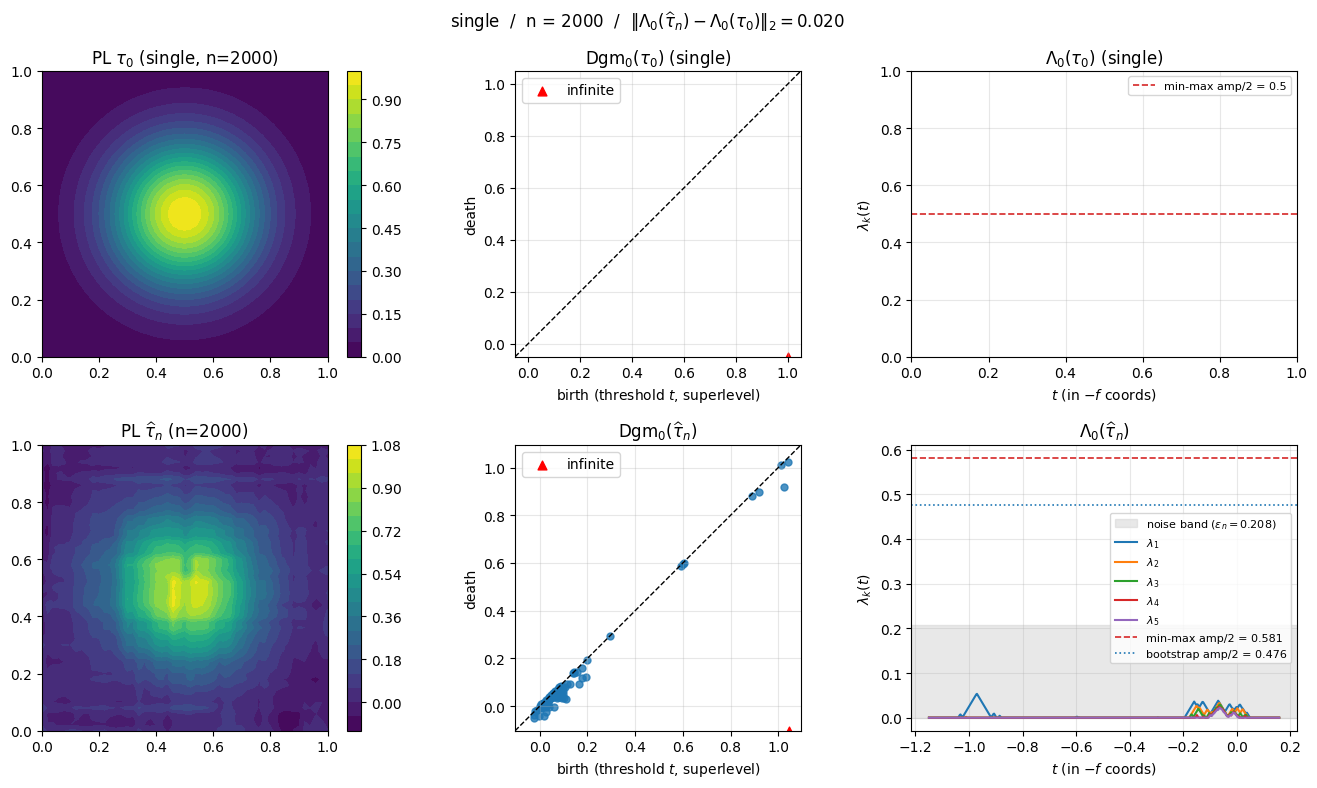

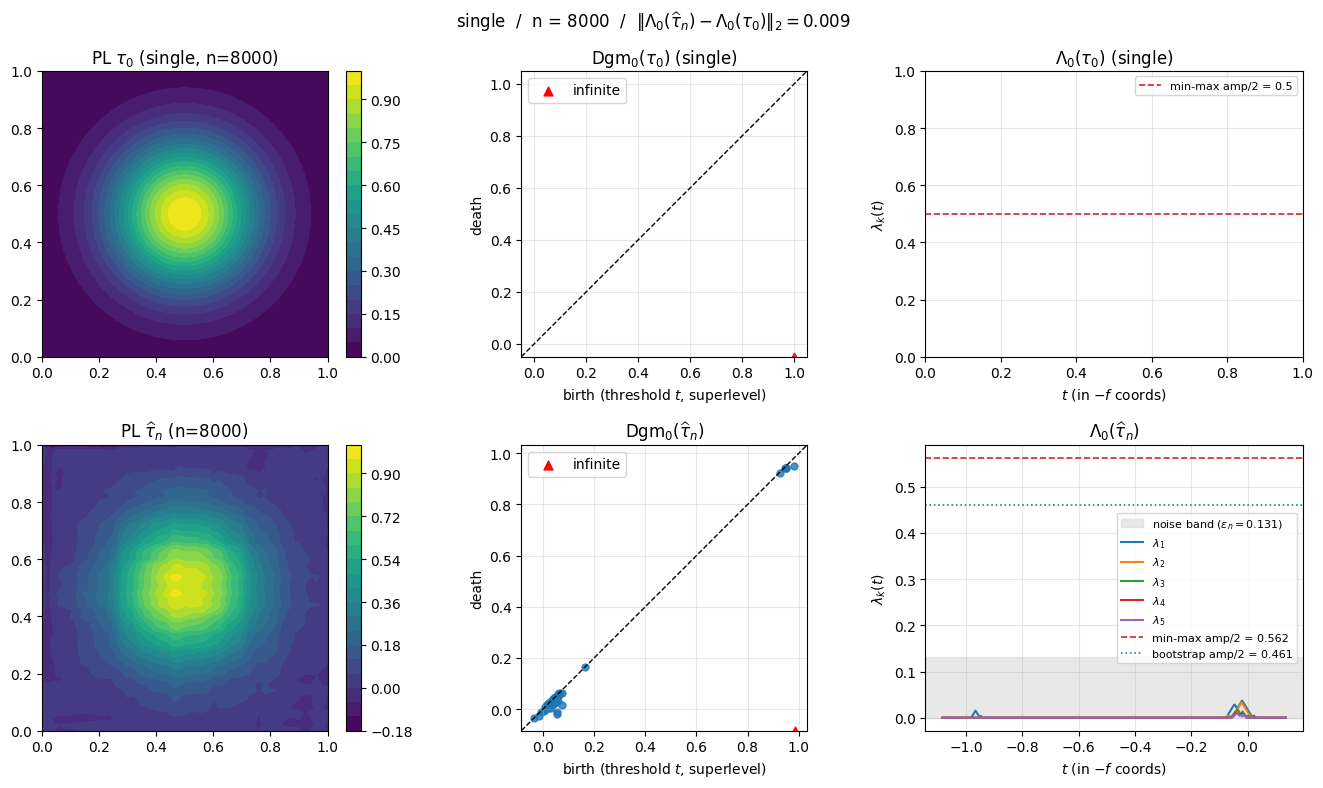

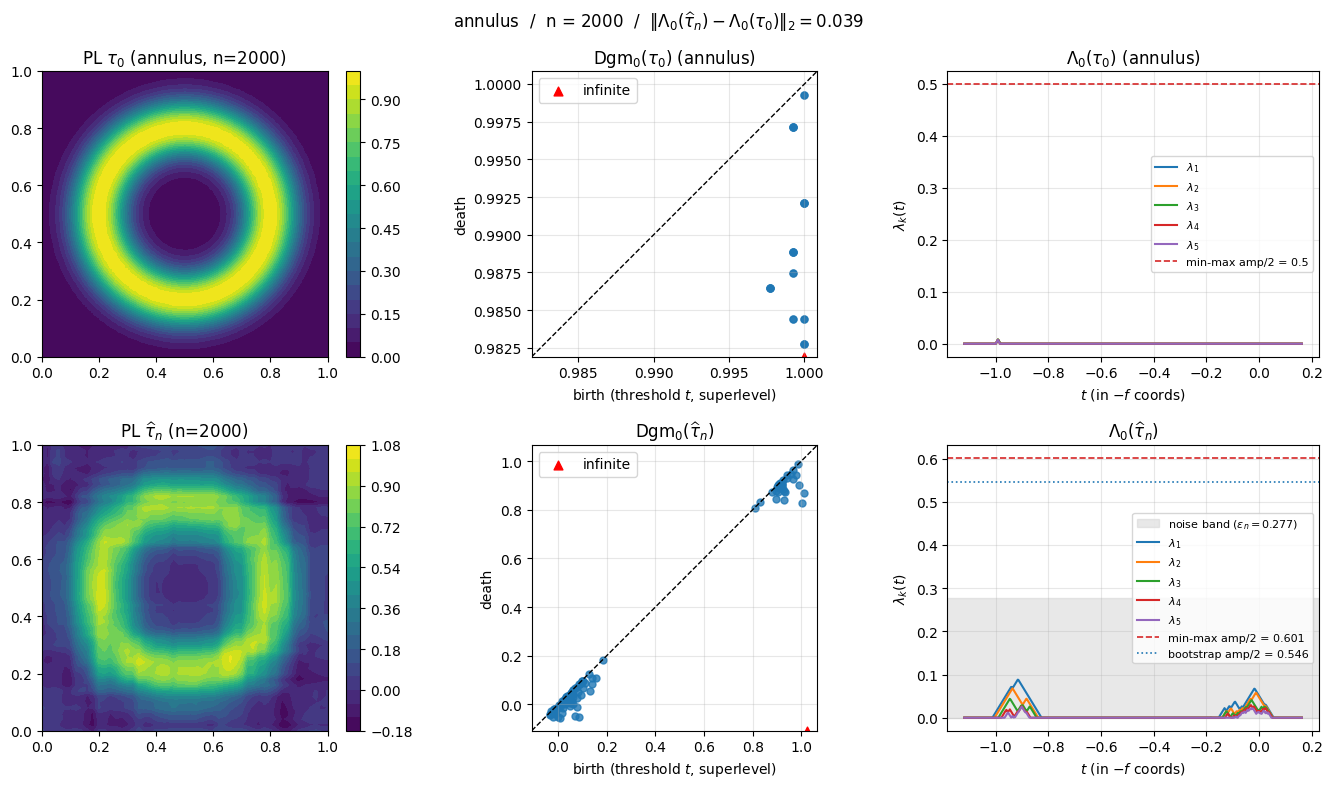

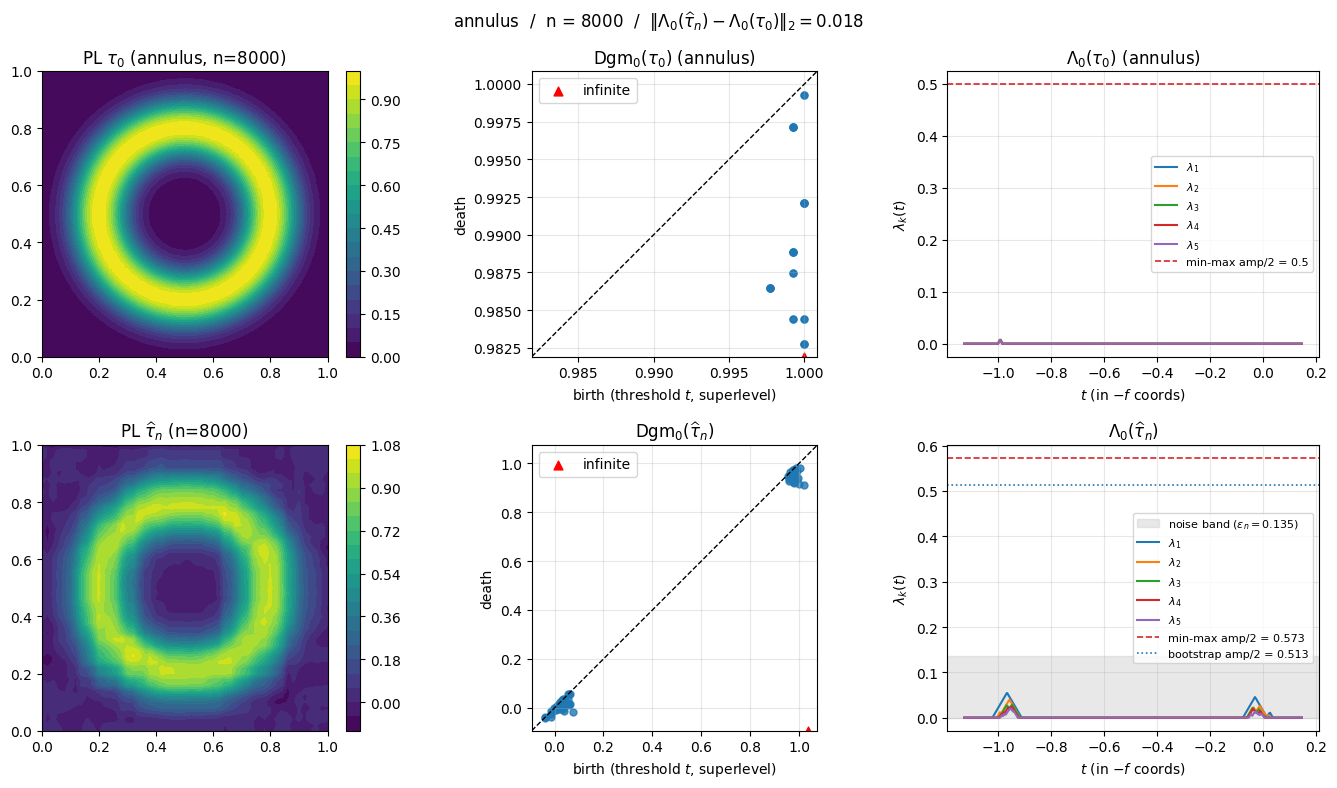

In [15]:
mesh_richer = triangulation.uniform_triangulation_2d(n_per_side=51)
BACKEND = 'catboost'    # try also 'xgboost', 'gbr'

topo_list = ['single', 'annulus']
n_list    = [2000, 8000]

results = {}
for topo in topo_list:
    for n in n_list:
        print(f'[ run ] topo={topo:12s}  n={n:5d}  backend={BACKEND}')
        results[(topo, n)] = run_topology_experiment(topo, n, mesh_richer, backend=BACKEND, noise_sd=0.05, seed=0, noise_band_alpha=0.5)

print('\n--- landscape distances ||Lambda_0(tau_hat) - Lambda_0(tau_0)||_p ---')
print(f'{"topology":12s}  {"n":>6s}    {"L1":>8s}    {"L2":>8s}    {"Linf":>8s}')
for (topo, n), res in results.items():
    d = res['dists']
    print(f'{topo:12s}  {n:6d}    {d["L1"]:8.4f}    {d["L2"]:8.4f}    {d["Linf"]:8.4f}')

for topo in topo_list:
    for n in n_list:
        res = results[(topo, n)]
        fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
        plotting.plot_pl_function(res['f_true'], mesh_richer, title=fr'PL $\tau_0$ ({topo}, n={n})', ax=axes[0, 0])
        plotting.plot_diagram(res['dgm_true_f'], title=fr'$\mathrm{{Dgm}}_0(\tau_0)$ ({topo})',     ax=axes[0, 1])
        plotting.plot_landscape(res['L_true'], title=fr'$\Lambda_0(\tau_0)$ ({topo})',              ax=axes[0, 2],
                                amplitude_minmax=res['amp_true'])
        plotting.plot_pl_function(res['f_hat'],  mesh_richer, title=fr'PL $\widehat\tau_n$ (n={n})', ax=axes[1, 0])
        plotting.plot_diagram(res['dgm_hat_f'],  title=fr'$\mathrm{{Dgm}}_0(\widehat\tau_n)$',       ax=axes[1, 1])
        plotting.plot_landscape(res['L_hat'],    title=fr'$\Lambda_0(\widehat\tau_n)$',              ax=axes[1, 2],
                                amplitude_minmax=res['scales'].amplitude_minmax,
                                amplitude_bootstrap=res['scales'].amplitude_bootstrap,
                                eps_n=res['scales'].eps_n)
        d = res['dists']
        fig.suptitle(fr'{topo}  /  n = {n}  /  '
                     fr'$\|\Lambda_0(\widehat\tau_n)-\Lambda_0(\tau_0)\|_2={d["L2"]:.3f}$',
                     fontsize=12)
        plt.tight_layout(); plt.show()

## 9.3 Denoised landscape grid: topologies × sample sizes

Below we visualise **denoised** persistence landscapes of $\widehat{\tau}_n$ across a sweep of topologies (rows) and sample sizes (columns).

We set `noise_band_alpha = 0.5`, so the noise band $\varepsilon_n$ is the **median** sup-deviation of $\widehat{\tau}_n$ across bootstrap replicates — a more permissive (less biased upward) threshold than the 95%-quantile.  Setting `denoised=True` in `plot_landscape` clips all landscape values below $\varepsilon_n$ to zero, leaving only the **topologically significant** tents — those that rise above the typical estimator noise floor.

Reading the grid:
- **Rows (top to bottom):** `annulus`, `single`, `two_blobs`, `three_blobs`, `four_blobs`.
- **Columns (left to right):** $n \in \{2000, 4000, 6000, 8000\}$.
- As $n$ grows, $\varepsilon_n$ shrinks and more genuine tents emerge from below the noise floor.

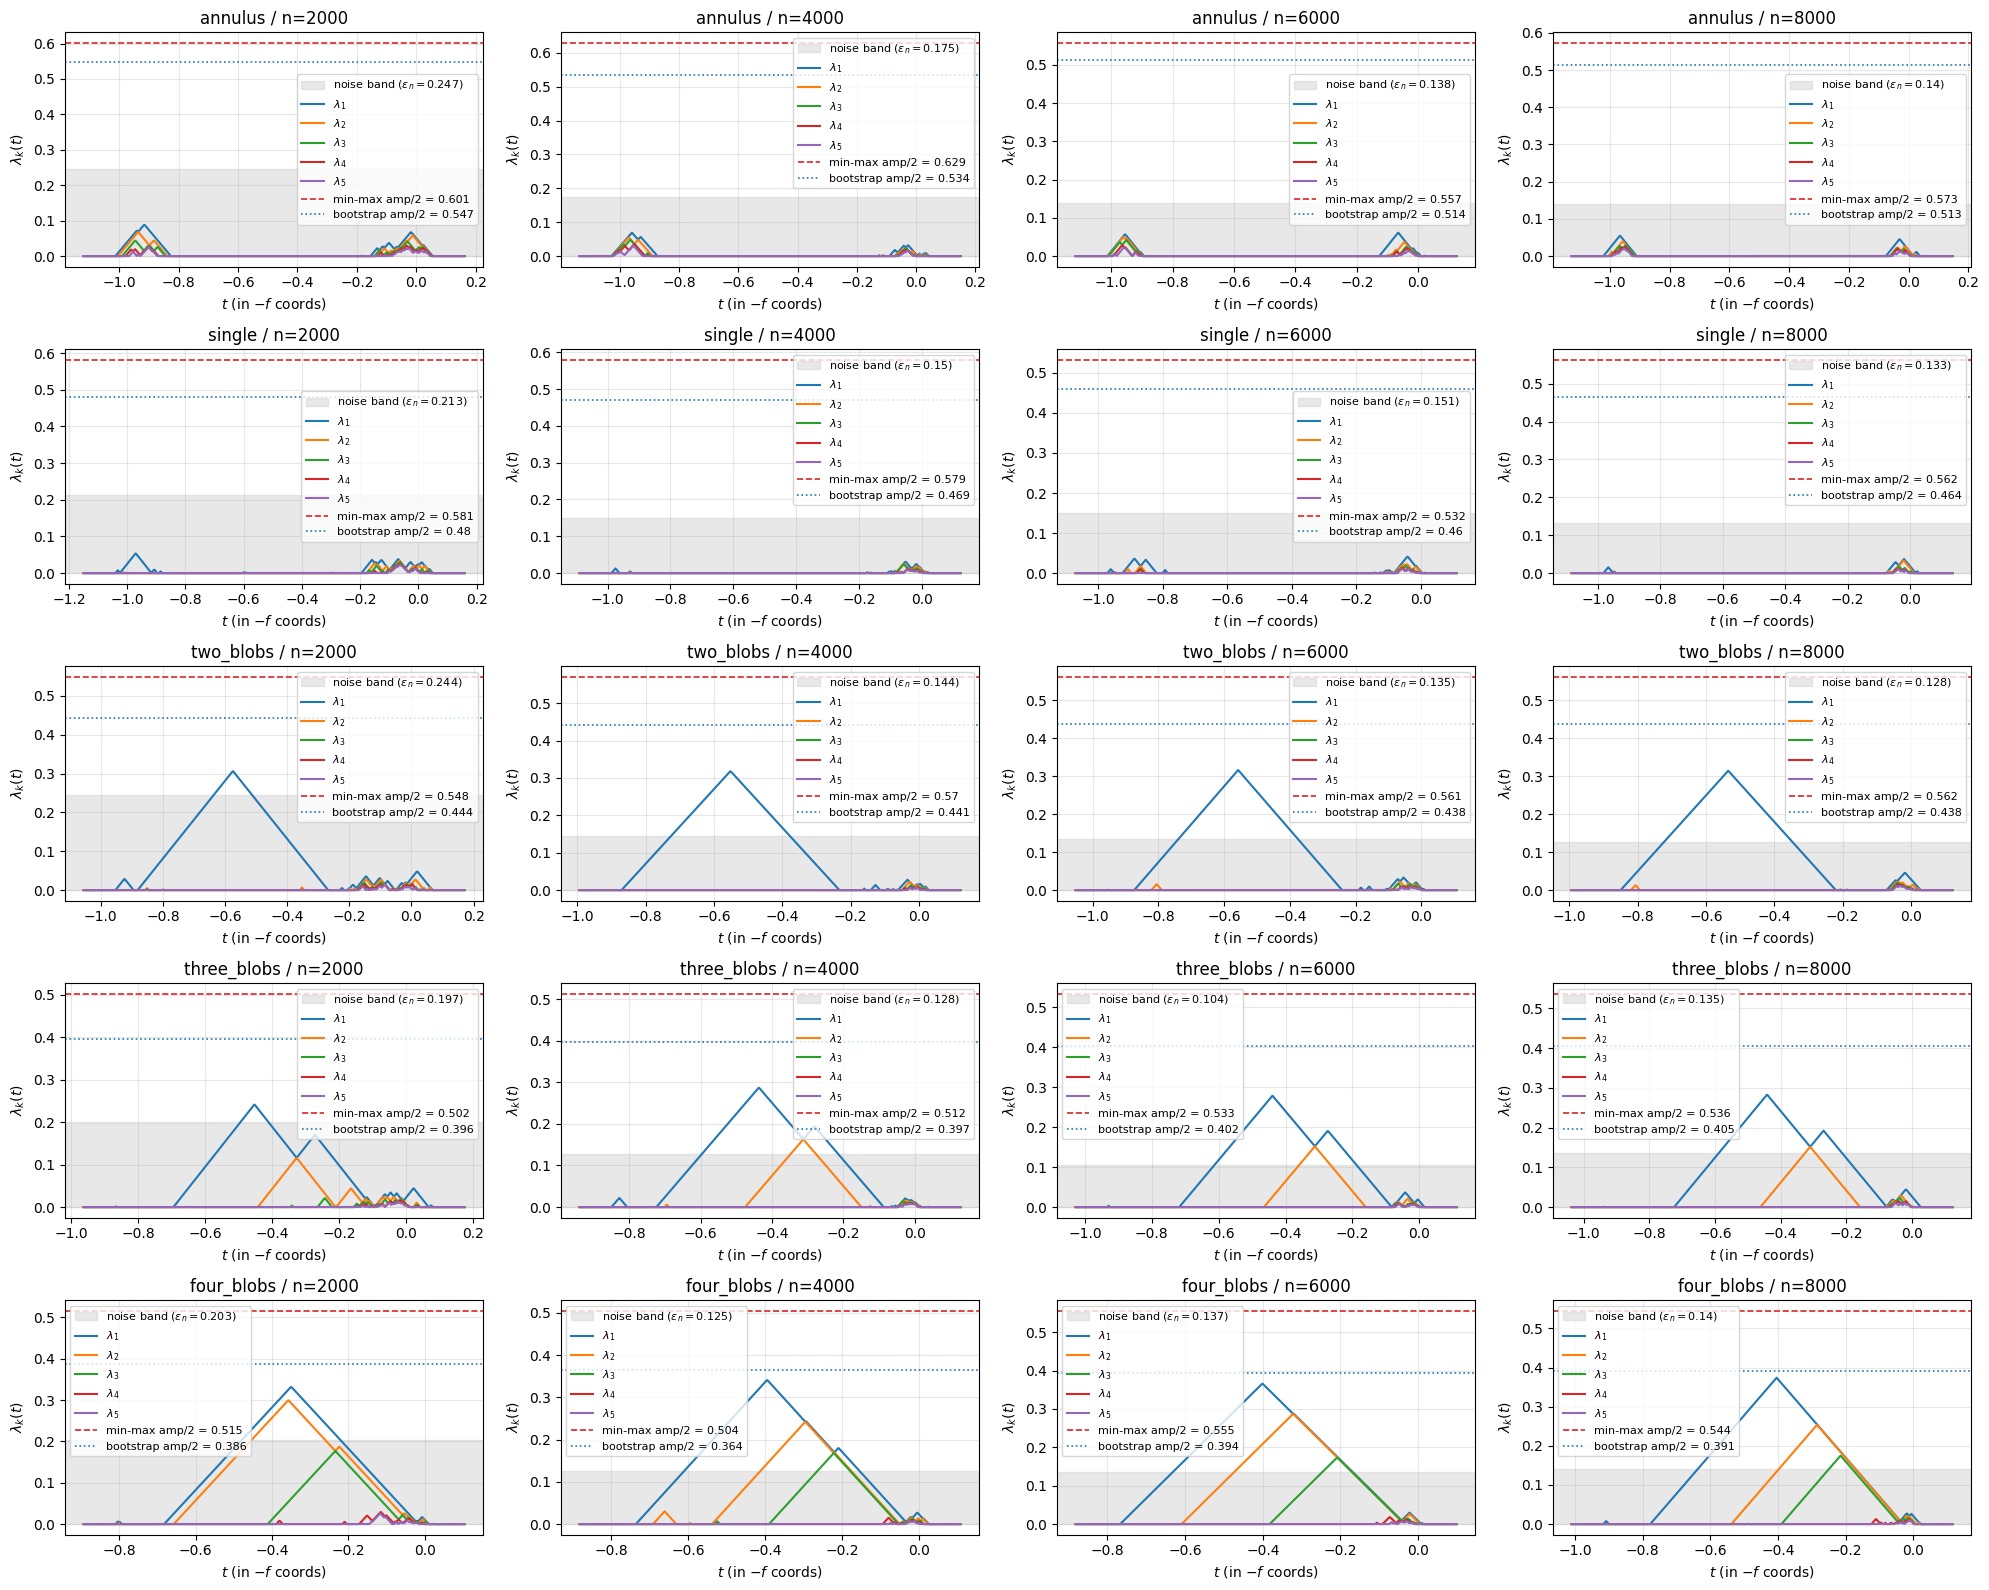

In [41]:
topo_list = ['annulus', 'single', 'two_blobs', 'three_blobs', 'four_blobs']
n_list = [2000, 4000, 6000, 8000]

fig, axes = plt.subplots(len(topo_list), len(n_list), figsize=(5.0 * len(n_list), 3.2 * len(topo_list)))

for i, topo in enumerate(topo_list):
    for j, n in enumerate(n_list):
        res = run_topology_experiment(
            topo, n, mesh_richer, n_bootstrap=10,
            backend='catboost', noise_sd=0.05, seed=0,
            noise_band_alpha=0.5,
        )
        plotting.plot_landscape(
            res['L_hat'],
            ax=axes[i, j],
            title=f'{topo} / n={n}',
            amplitude_minmax=res['scales'].amplitude_minmax,
            amplitude_bootstrap=res['scales'].amplitude_bootstrap,
            eps_n=res['scales'].eps_n,
        )

plt.tight_layout()
plt.show()

### Quantitative landscape error: $L_2$ and $L_\infty$ norms

The grid above gives a visual sense of how $\widehat{\Lambda}_n$ converges to $\Lambda$ as $n$ grows.  We now quantify this directly by computing $\|\Lambda - \widehat{\Lambda}_n\|_2$ and $\|\Lambda - \widehat{\Lambda}_n\|_\infty$ for the same topology × $n$ sweep.  Bootstrap-based scale estimation is skipped here — we only need the two landscapes themselves, which makes the cell dramatically faster.

### Quantitative landscape error: $L_1$, $L_2$ and $L_\infty$ norms (10 seeds)

We now quantify how $\widehat{\Lambda}_n$ approaches $\Lambda$ as $n$ grows.  Recall the $L_p$ landscape distance (Bubenik, 2015):

$$
\bigl\| \Lambda - \widehat{\Lambda}_n \bigr\|_p \;=\; \left( \sum_{k\ge 1} \int_{\mathbb{R}} \bigl| \lambda_k(t) - \widehat{\lambda}_{k,n}(t) \bigr|^p \, dt \right)^{1/p}, \qquad p \in \{1, 2\},
$$

$$
\bigl\| \Lambda - \widehat{\Lambda}_n \bigr\|_\infty \;=\; \sup_{k \ge 1, \; t \in \mathbb{R}} \bigl| \lambda_k(t) - \widehat{\lambda}_{k,n}(t) \bigr|.
$$

For each topology and sample size $n$ we repeat the experiment over **10 random seeds** and report the empirical mean $\pm$ standard deviation.  Bootstrap-based scale estimation is skipped, as we only need the two landscapes themselves.

In [59]:
from IPython.display import display, Markdown

def landscape_errors(topo, n, mesh, *, backend='catboost', noise_sd=0.05, seed=0):
    """Fit tau_hat, build true and estimated H_0 landscapes, return L1/L2/Linf distances.

    Skips estimate_tau_scales for speed (no bootstrap).
    """
    ds = data.make_topology_dgp(n=n, topology=topo, noise_sd=noise_sd, seed=seed)
    est = cate.RLearnerCATE(backend=backend, n_folds=5, seed=seed).fit(ds.X, ds.A, ds.Y)

    f_true_vals = triangulation.pl_interpolate(ds.tau0,    mesh)
    f_hat_vals  = triangulation.pl_interpolate(est.predict, mesh)

    dgm_true_neg = topology.persistence_h0_superlevel(f_true_vals, mesh, return_in_f_coords=False)
    dgm_hat_neg  = topology.persistence_h0_superlevel(f_hat_vals,  mesh, return_in_f_coords=False)

    grid = landscape.auto_grid([dgm_true_neg, dgm_hat_neg], n_points=512, pad=0.1)
    L_true = landscape.compute_landscape(dgm_true_neg, grid)
    L_hat  = landscape.compute_landscape(dgm_hat_neg,  grid)

    return {
        'L1':   landscape.landscape_distance(L_true, L_hat, p=1.0),
        'L2':   landscape.landscape_distance(L_true, L_hat, p=2.0),
        'Linf': landscape.landscape_distance(L_true, L_hat, p=np.inf),
    }


topo_list = ['annulus', 'single', 'two_blobs', 'three_blobs', 'four_blobs']
n_list = [2000, 4000, 6000, 8000]
seeds = list(range(10))
norm_keys = ['L1', 'L2', 'Linf']

rows = []
for topo in topo_list:
    for n in n_list:
        per_seed = {k: [] for k in norm_keys}
        for seed in seeds:
            errs = landscape_errors(topo, n, mesh_richer, backend='catboost', noise_sd=0.05, seed=seed)
            for k in norm_keys:
                per_seed[k].append(errs[k])
        row = {'topology': topo, 'n': n}
        for k in norm_keys:
            arr = np.asarray(per_seed[k], dtype=float)
            row[f'{k}_mean'] = float(arr.mean())
            row[f'{k}_std']  = float(arr.std(ddof=1))
        rows.append(row)

err_df = pd.DataFrame(rows)

def _format_table(df, key, label_tex):
    mean_tbl = df.pivot(index='topology', columns='n', values=f'{key}_mean').reindex(topo_list)
    std_tbl  = df.pivot(index='topology', columns='n', values=f'{key}_std').reindex(topo_list)
    formatted = mean_tbl.copy().astype(object)
    for i in mean_tbl.index:
        for j in mean_tbl.columns:
            formatted.loc[i, j] = f'{mean_tbl.loc[i, j]:.4f} \u00b1 {std_tbl.loc[i, j]:.4f}'
    display(Markdown(f'**{label_tex}**  (mean $\\pm$ std over {len(seeds)} seeds)'))
    display(formatted)

_format_table(err_df, 'L1',   r'$\|\Lambda - \widehat{\Lambda}_n\|_1 = \sum_k \int |\lambda_k - \widehat{\lambda}_{k,n}| \, dt$')
_format_table(err_df, 'L2',   r'$\|\Lambda - \widehat{\Lambda}_n\|_2 = \Bigl(\sum_k \int (\lambda_k - \widehat{\lambda}_{k,n})^2 \, dt\Bigr)^{1/2}$')
_format_table(err_df, 'Linf', r'$\|\Lambda - \widehat{\Lambda}_n\|_\infty = \sup_{k, t} |\lambda_k(t) - \widehat{\lambda}_{k,n}(t)|$')

**$\|\Lambda - \widehat{\Lambda}_n\|_1 = \sum_k \int |\lambda_k - \widehat{\lambda}_{k,n}| \, dt$**  (mean $\pm$ std over 10 seeds)

n,2000,4000,6000,8000
topology,,,,
annulus,0.0448 ± 0.0116,0.0263 ± 0.0047,0.0214 ± 0.0045,0.0173 ± 0.0037
single,0.0162 ± 0.0064,0.0089 ± 0.0041,0.0075 ± 0.0035,0.0064 ± 0.0055
two_blobs,0.0345 ± 0.0156,0.0269 ± 0.0102,0.0210 ± 0.0083,0.0202 ± 0.0130
three_blobs,0.0719 ± 0.0110,0.0511 ± 0.0097,0.0453 ± 0.0114,0.0438 ± 0.0063
four_blobs,0.0855 ± 0.0179,0.0624 ± 0.0172,0.0568 ± 0.0083,0.0527 ± 0.0072


**$\|\Lambda - \widehat{\Lambda}_n\|_2 = \Bigl(\sum_k \int (\lambda_k - \widehat{\lambda}_{k,n})^2 \, dt\Bigr)^{1/2}$**  (mean $\pm$ std over 10 seeds)

n,2000,4000,6000,8000
topology,,,,
annulus,0.0429 ± 0.0090,0.0277 ± 0.0034,0.0240 ± 0.0045,0.0203 ± 0.0040
single,0.0197 ± 0.0065,0.0134 ± 0.0067,0.0115 ± 0.0044,0.0108 ± 0.0087
two_blobs,0.0348 ± 0.0162,0.0286 ± 0.0123,0.0241 ± 0.0099,0.0242 ± 0.0161
three_blobs,0.0683 ± 0.0123,0.0488 ± 0.0108,0.0443 ± 0.0122,0.0427 ± 0.0056
four_blobs,0.0687 ± 0.0120,0.0504 ± 0.0126,0.0452 ± 0.0068,0.0430 ± 0.0053


**$\|\Lambda - \widehat{\Lambda}_n\|_\infty = \sup_{k, t} |\lambda_k(t) - \widehat{\lambda}_{k,n}(t)|$**  (mean $\pm$ std over 10 seeds)

n,2000,4000,6000,8000
topology,,,,
annulus,0.0957 ± 0.0178,0.0690 ± 0.0062,0.0629 ± 0.0131,0.0585 ± 0.0116
single,0.0609 ± 0.0184,0.0480 ± 0.0234,0.0426 ± 0.0128,0.0409 ± 0.0273
two_blobs,0.0706 ± 0.0189,0.0529 ± 0.0205,0.0468 ± 0.0142,0.0513 ± 0.0226
three_blobs,0.1034 ± 0.0216,0.0664 ± 0.0165,0.0624 ± 0.0230,0.0590 ± 0.0101
four_blobs,0.0864 ± 0.0155,0.0593 ± 0.0134,0.0525 ± 0.0119,0.0517 ± 0.0078
